Pandas Data Operations

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('students.csv')
df

,rollno,name,city,age,marks
0,101,Roger,California,20.0,85.0
1,102,Sam,NaN,22.0,NaN
2,103,Peter,Paris,NaN,95.0
3,104,Alex,LA,18.0,91.0
4,105,Alexa,San Fransisco,21.0,NaN
5,106,John,NaN,NaN,88.0
6,106,George,LA,22.0,50.0


In [3]:
df['city'].fillna('Not Available',inplace=True)
df

C:\Users\Admin\AppData\Local\Temp\ipykernel_2176\3050181235.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['city'].fillna('Not Available',inplace=True)


,rollno,name,city,age,marks
0,101,Roger,California,20.0,85.0
1,102,Sam,Not Available,22.0,NaN
2,103,Peter,Paris,NaN,95.0
3,104,Alex,LA,18.0,91.0
4,105,Alexa,San Fransisco,21.0,NaN
5,106,John,Not Available,NaN,88.0
6,106,George,LA,22.0,50.0


In [4]:
average_age = int(df['age'].mean())
df['age'].fillna(average_age,inplace=True)
df

C:\Users\Admin\AppData\Local\Temp\ipykernel_2176\1022320365.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(average_age,inplace=True)


,rollno,name,city,age,marks
0,101,Roger,California,20.0,85.0
1,102,Sam,Not Available,22.0,NaN
2,103,Peter,Paris,20.0,95.0
3,104,Alex,LA,18.0,91.0
4,105,Alexa,San Fransisco,21.0,NaN
5,106,John,Not Available,20.0,88.0
6,106,George,LA,22.0,50.0


In [5]:
df['marks'].fillna(0,inplace=True)
df

C:\Users\Admin\AppData\Local\Temp\ipykernel_2176\1007058349.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['marks'].fillna(0,inplace=True)


,rollno,name,city,age,marks
0,101,Roger,California,20.0,85.0
1,102,Sam,Not Available,22.0,0.0
2,103,Peter,Paris,20.0,95.0
3,104,Alex,LA,18.0,91.0
4,105,Alexa,San Fransisco,21.0,0.0
5,106,John,Not Available,20.0,88.0
6,106,George,LA,22.0,50.0


Add a category column in the dataframe that has two categories
- PASS - if student has marks 50 or above
- FAIL - if student has marks below 50

In [6]:
def getresult(marks):
    if marks >= 50: return 'PASS'
    else: return 'FAIL'

In [7]:
df['result'] = df['marks'].apply(getresult)

In [8]:
df

,rollno,name,city,age,marks,result
0,101,Roger,California,20.0,85.0,PASS
1,102,Sam,Not Available,22.0,0.0,FAIL
2,103,Peter,Paris,20.0,95.0,PASS
3,104,Alex,LA,18.0,91.0,PASS
4,105,Alexa,San Fransisco,21.0,0.0,FAIL
5,106,John,Not Available,20.0,88.0,PASS
6,106,George,LA,22.0,50.0,PASS


Calculate the grades
- If marks 75 or above - A
- If marks 65 or above - B
- If marks 50 or above - C
- If marks below 50    - F

We have to do it using Binning Process

In [9]:
marks_ranges = [0, 49, 64, 74, 100]
grade_labels = ['F','C','B','A']

df['grades'] = pd.cut(df['marks'],bins=marks_ranges,labels=grade_labels,include_lowest=True)

df

,rollno,name,city,age,marks,result,grades
0,101,Roger,California,20.0,85.0,PASS,A
1,102,Sam,Not Available,22.0,0.0,FAIL,F
2,103,Peter,Paris,20.0,95.0,PASS,A
3,104,Alex,LA,18.0,91.0,PASS,A
4,105,Alexa,San Fransisco,21.0,0.0,FAIL,F
5,106,John,Not Available,20.0,88.0,PASS,A
6,106,George,LA,22.0,50.0,PASS,C


In [10]:
resultwise_group = df.groupby(df['result'])
resultwise_group

In [15]:
resultwise_count = resultwise_group['rollno'].count()
resultwise_count 

result
FAIL    2
PASS    5
Name: rollno, dtype: int64

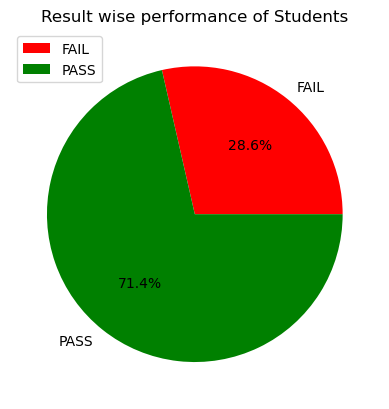

In [29]:
plt.pie(resultwise_count,colors=['red','green'],labels=['FAIL','PASS'],autopct='%1.1f%%')
plt.title('Result wise performance of Students')
plt.legend()
plt.show()

In [14]:
gradewise_performance = df.groupby(df['grades'])
gradewise_performance['rollno'].count()

C:\Users\Admin\AppData\Local\Temp\ipykernel_2176\2971060854.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gradewise_performance = df.groupby(df['grades'])


grades
F    2
C    1
B    0
A    4
Name: rollno, dtype: int64

<BarContainer object of 3 artists>

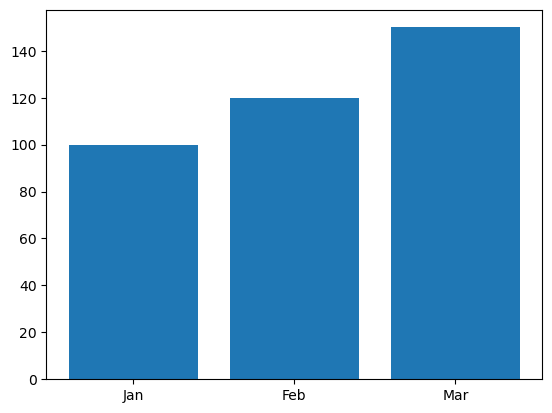

In [42]:
x = np.array(['Jan','Feb','Mar'])
y = np.array([100,120,150])

plt.bar(x,y)